# CSCE 40103 Module 3, Lecture 3

## Full BERT Demo for Google Colab

This notebook demonstrates the full `bert-base-uncased` model using Hugging Face Transformers and PyTorch.

Use this notebook in a standard Python kernel, not a Pyodide kernel.

What this notebook does:

1. Loads a small classroom ham/spam dataset.
2. Loads the full `bert-base-uncased` tokenizer and model.
3. Converts messages into BERT `[CLS]` embeddings.
4. Trains an MLP classifier on top of those embeddings.
5. Evaluates the detector and tests safe classroom messages.

In [1]:
# Required packages for the full BERT demo.
# Run this in VS Code, or Google Colab.
# Do not run this in Pyodide.

# %pip install -q pandas numpy scikit-learn matplotlib seaborn transformers torch accelerate

## 1. Import packages and check environment

In [2]:
import sys
import platform
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import torch
from transformers import AutoTokenizer, AutoModel

IN_PYODIDE = (platform.system() == "Emscripten") or ("pyodide" in sys.modules)

print("Python version:", sys.version.split()[0])
print("Platform:", platform.system())
print("Running in Pyodide:", IN_PYODIDE)
print("Torch version:", torch.__version__)

if IN_PYODIDE:
    raise RuntimeError("This full BERT notebook must be run in a standard Python kernel, not Pyodide.")

/Users/bryant/aiForSecurity/module3/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python version: 3.14.5
Platform: Darwin
Running in Pyodide: False
Torch version: 2.12.0


## 2. Create the classroom dataset

In [3]:
# Small classroom dataset created for Module 3.
# Labels are ham/spam, not true phishing labels.
# This dataset is intentionally small so students can understand every example.

data = [
    # Ham / legitimate messages
    {"text": "Reminder your project notebook is due Friday on Blackboard", "label": "ham"},
    {"text": "The review session for exam two is tomorrow afternoon", "label": "ham"},
    {"text": "Please submit your lab report through the course website", "label": "ham"},
    {"text": "Office hours are moved to Thursday morning", "label": "ham"},
    {"text": "Your scholarship form is due today use the official university portal", "label": "ham"},
    {"text": "Free tutoring is available before the final exam", "label": "ham"},
    {"text": "Team meeting moved to 3 pm in the engineering building", "label": "ham"},
    {"text": "Blackboard maintenance will happen this weekend", "label": "ham"},
    {"text": "Your course survey is available in the official portal", "label": "ham"},
    {"text": "Project feedback has been posted on Blackboard", "label": "ham"},
    {"text": "Reminder the class presentation schedule is posted", "label": "ham"},
    {"text": "Your advising appointment is confirmed for Monday", "label": "ham"},
    {"text": "Please review the syllabus update before next class", "label": "ham"},
    {"text": "The department seminar starts at noon", "label": "ham"},
    {"text": "Your library book renewal confirmation is complete", "label": "ham"},
    {"text": "The campus network maintenance window starts tonight", "label": "ham"},

    # Spam / suspicious messages
    {"text": "Claim your free prize now click the link", "label": "spam"},
    {"text": "Congratulations you won a free gift card claim today", "label": "spam"},
    {"text": "Your account will expire today review your access now", "label": "spam"},
    {"text": "Urgent verify your password immediately", "label": "spam"},
    {"text": "Free money waiting for you claim your reward", "label": "spam"},
    {"text": "Your mailbox storage is full update your account immediately", "label": "spam"},
    {"text": "Limited time offer click now to claim your reward", "label": "spam"},
    {"text": "Verify your login profile or your account will be suspended", "label": "spam"},
    {"text": "Password reset required click to continue", "label": "spam"},
    {"text": "Act now your account access expires in two hours", "label": "spam"},
    {"text": "You have been selected for a cash reward", "label": "spam"},
    {"text": "Urgent account review required confirm your identity", "label": "spam"},
    {"text": "Prize claim deadline today open this link", "label": "spam"},
    {"text": "Payment refund available confirm your profile", "label": "spam"},
    {"text": "Security alert verify your account access immediately", "label": "spam"},
    {"text": "Your email access will be disabled unless you update your profile", "label": "spam"},
]

df = pd.DataFrame(data)
display(df.head())
print("Dataset shape:", df.shape)
print("Class counts:")
print(df["label"].value_counts())

,text,label
0,Reminder your project notebook is due Friday o...,ham
1,The review session for exam two is tomorrow af...,ham
2,Please submit your lab report through the cour...,ham
3,Office hours are moved to Thursday morning,ham
4,Your scholarship form is due today use the off...,ham


Dataset shape: (32, 2)
Class counts:
label
ham     16
spam    16
Name: count, dtype: int64


## 3. Train-test split

In [4]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))
print("Training class counts:")
print(y_train.value_counts())
print("Testing class counts:")
print(y_test.value_counts())

Training examples: 24
Testing examples: 8
Training class counts:
label
spam    12
ham     12
Name: count, dtype: int64
Testing class counts:
label
spam    4
ham     4
Name: count, dtype: int64


## 4. Load full BERT

We use `bert-base-uncased`, the full BERT base model.

This model reads text with bidirectional context, meaning it uses words on both the left and right side to build context-aware representations.

In [5]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)
bert_model.eval()

print("Loaded:", MODEL_NAME)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7638.85it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: bert-base-uncased


## 5. Tokenize one message

This shows how BERT prepares a message before the neural network reads it.

In [6]:
message = "Your account access will expire today."

encoded = tokenizer(
    message,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])

print("Original message:", message)
print("BERT tokens:")
print(tokens)

Original message: Your account access will expire today.
BERT tokens:
['[CLS]', 'your', 'account', 'access', 'will', 'ex', '##pire', 'today', '.', '[SEP]']


## 6. Convert messages into BERT embeddings

We use the `[CLS]` embedding as a compact representation of the whole message.

Plain idea:

- BERT reads the message.
- BERT creates a vector representation.
- The classifier learns from those vectors.

In [7]:
def make_bert_embeddings(texts, batch_size=4, max_length=64):
    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        batch_texts = list(texts[start:start + batch_size])

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = bert_model(**inputs)

        # Shape: batch_size x hidden_size
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)

X_train_bert = make_bert_embeddings(X_train.to_numpy())
X_test_bert = make_bert_embeddings(X_test.to_numpy())

print("Training embedding matrix:", X_train_bert.shape)
print("Testing embedding matrix:", X_test_bert.shape)

Training embedding matrix: (24, 768)
Testing embedding matrix: (8, 768)


## 7. Train an MLP classifier on BERT embeddings

BERT creates the representation.

The MLP learns the final ham/spam decision from that representation.

In [8]:
bert_mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="lbfgs",
    alpha=0.001,
    max_iter=1000,
    random_state=42
)

bert_mlp.fit(X_train_bert, y_train)
predictions = bert_mlp.predict(X_test_bert)

print(classification_report(y_test, predictions, zero_division=0))

              precision    recall  f1-score   support

         ham       0.80      1.00      0.89         4
        spam       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



## 8. Confusion matrix

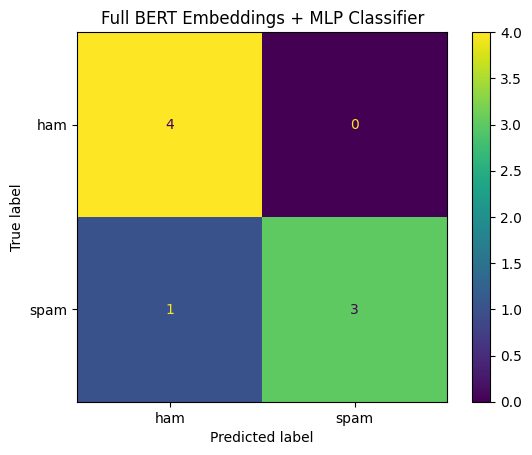

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("Full BERT Embeddings + MLP Classifier")
plt.show()

## 9. Test safe classroom messages

In [10]:
new_messages = [
    "Your account access will expire today review your profile now",
    "Free tutoring is available before the exam",
    "Free prize waiting for you click now",
    "Reminder your final project notebook is due Friday on Blackboard",
    "Review your access profile today"
]

new_embeddings = make_bert_embeddings(new_messages)
new_predictions = bert_mlp.predict(new_embeddings)

for message, prediction in zip(new_messages, new_predictions):
    print(f"Prediction: {prediction:4s} | Message: {message}")

Prediction: spam | Message: Your account access will expire today review your profile now
Prediction: ham  | Message: Free tutoring is available before the exam
Prediction: spam | Message: Free prize waiting for you click now
Prediction: ham  | Message: Reminder your final project notebook is due Friday on Blackboard
Prediction: spam | Message: Review your access profile today


## 10. Important limitation

This is a full BERT representation demo, not full BERT fine-tuning.

A real BERT-based phishing detector would need:

- a larger labeled dataset
- phishing-specific labels
- train, validation, and test splits
- careful fine-tuning
- threshold selection based on mistake cost
- evaluation against new attack wording

Security reminder:

BERT can understand more context than Bag-of-Words or TF-IDF, but it can still fail if the training labels are weak, outdated, or mismatched to the real task.